In this notebook we will implement all changes to the data discovered during EDA.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, FunctionTransformer, TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import joblib

In [2]:
train = pd.read_csv('data/train.csv')
score = pd.read_csv('data/score.csv')

# Data prep

## Converitng data types

In [3]:
# convert date columns to datetime format
date_columns = ["snapshot_date", "policy_effective_date", "policy_expiration_date", "first_claim_reported_date"]

for col in date_columns:
    train[col] = pd.to_datetime(train[col], errors='coerce')
    score[col] = pd.to_datetime(score[col], errors='coerce')

# extract policy year for train to use later train/test split
train['policy_year'] = train['policy_effective_date'].dt.year

In [4]:
# clean text columns by stripping whitespace and converting to lowercase
text_columns = ["business_type", "state", "payment_frequency"]

for col in text_columns:
    train[col] = train[col].str.strip().str.lower()
    score[col] = score[col].str.strip().str.lower()

## Missing values

In [5]:
# fill missing values in risk_score_external with average by business_type and coverage_type
def impute_risk_score(df: pd.DataFrame) -> pd.DataFrame:
    df_cleaned = df.copy()
    
    group_means = df_cleaned.groupby(['business_type', 'coverage_type'])['risk_score_external'].transform('mean')
    
    df_cleaned['risk_score_external'] = df_cleaned['risk_score_external'].fillna(group_means)
    
    global_mean = df_cleaned['risk_score_external'].mean()
    df_cleaned['risk_score_external'] = df_cleaned['risk_score_external'].fillna(global_mean)
    
    return df_cleaned

In [6]:
train = impute_risk_score(train)
score = impute_risk_score(score)

In [7]:
# fill missing values for numeric columns with 0
train[train.select_dtypes("number").columns] = train.select_dtypes("number").fillna(0)
score[score.select_dtypes("number").columns] = score.select_dtypes("number").fillna(0)

In [8]:
# fill missing values for payment_frequency columns with 'missing'
train['payment_frequency'] = train['payment_frequency'].fillna('missing')
score['payment_frequency'] = score['payment_frequency'].fillna('missing')

## Prepare target variable

In [9]:
# ---- target ----
# using binary had-a-claim flag as target
train["target"] = (train["claim_count"] > 0).astype(int)

## Data split

In [10]:
# split the dataset based on the coverage
train_al = train[train['coverage_type'] == 'AL'].copy()
train_apd = train[train['coverage_type'] == 'APD'].copy()

score_al = score[score['coverage_type'] == 'AL'].copy()
score_apd = score[score['coverage_type'] == 'APD'].copy()

## Handle outliers

In [11]:
# delete rows with vehicle_count = 0
train_apd = train_apd[train_apd['vehicle_count'] > 0].copy()

score_apd = score_apd[score_apd['vehicle_count'] > 0].copy()

In [12]:
# filtering out rows with annual premium less than or equal to 0
train_al = train_al[train_al['annual_premium'] > 0].copy()
train_apd = train_apd[train_apd['annual_premium'] > 0].copy()

score_al = score_al[score_al['annual_premium'] > 0].copy()
score_apd = score_apd[score_apd['annual_premium'] > 0].copy()

In [13]:
score_al.to_csv('data/01_score_al.csv', index=False)
score_apd.to_csv('data/01_score_apd.csv', index=False)

# Modeling

## Feature selection

Select features for both subset based on EDA.

In [14]:
feat_cols_al = ["vehicle_count", "num_heavy_vehicles", "risk_score_external", "prior_year_mileage_000", "prior_al_claim_count",
                "driver_count", "vehicle_avg_age", "late_payment_count", "coverage_limit_000", "prior_loss_amount", 
                "business_type", "payment_frequency", "state", "deductible"]

feat_cols_apd = ["vehicle_count", "num_heavy_vehicles", "risk_score_external", "prior_year_mileage_000", "prior_apd_claim_count",
                "driver_count", "vehicle_avg_age", "late_payment_count", "coverage_limit_000", "prior_loss_amount", "annual_premium",
                "years_in_business",
                "business_type", "payment_frequency", "state", "deductible"]

In [15]:
X_al = train_al[feat_cols_al + ["policy_year"]]
y_al = train_al[["target", "policy_year"]]

X_apd = train_apd[feat_cols_apd + ["policy_year"]]
y_apd = train_apd[["target", "policy_year"]]

## Train, test split

In [16]:
X_al_train = X_al[X_al['policy_year'].isin([2019, 2020, 2021])].drop(columns=['policy_year']).copy()
X_al_test = X_al[X_al['policy_year'].isin([2022])].drop(columns=['policy_year']).copy()

X_apd_train = X_apd[X_apd['policy_year'].isin([2019, 2020, 2021])].drop(columns=['policy_year']).copy()
X_apd_test = X_apd[X_apd['policy_year'].isin([2022])].drop(columns=['policy_year']).copy()

y_al_train = y_al[y_al['policy_year'].isin([2019, 2020, 2021])].drop(columns=['policy_year']).copy()
y_al_test = y_al[y_al['policy_year'].isin([2022])].drop(columns=['policy_year']).copy()

y_apd_train = y_apd[y_apd['policy_year'].isin([2019, 2020, 2021])].drop(columns=['policy_year']).copy()
y_apd_test = y_apd[y_apd['policy_year'].isin([2022])].drop(columns=['policy_year']).copy()

## Modeling pipeline

Becuase of business types mismatch between training and scoring dataset encoding, standardization, model fit need to be done in pipeline that will handle this.

In [17]:
num_cols = [col for col in train.select_dtypes(include=[np.number]).columns if col not in ["target", "claim_count", "has_safety_program"]]
num_cols_al = [col for col in num_cols if col in X_al_train.columns]
num_cols_apd = [col for col in num_cols if col in X_apd_train.columns]

skewed_cols = ['prior_loss_amount', 'annual_premium', 'prior_year_mileage_000', 'vehicle_count', 'driver_count']
skewed_cols_al = [col for col in skewed_cols if col in X_al_train.columns]
skewed_cols_apd = [col for col in skewed_cols if col in X_apd_train.columns]

low_cardinality_cols = ['business_type', 'payment_frequency']

high_cardinality_cols = ['state']

In [18]:
def build_and_tune_pipeline(X_train: pd.DataFrame, y_train: pd.Series, skewed_cols: list, num_cols: list, low_card_cols: list, high_card_cols: list) -> Pipeline:

    skewed_transformer = Pipeline(steps=[
    ('log1p', FunctionTransformer(np.log1p))
    ])
    
    regular_transformer = RobustScaler()
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num_skewed', skewed_transformer, skewed_cols),
            ('num_regular', regular_transformer, num_cols),
            ('cat_ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), low_card_cols),
            ('cat_te', TargetEncoder(smooth="auto"), high_card_cols) 
        ]
    )
    
    full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, solver='saga', random_state=42, class_weight='balanced'))
    ])
    
    # Hyperparameter Grid
    param_grid = {
        'classifier__C': [0.001, 0.01, 0.1, 1.0, 10.0],
        'classifier__l1_ratio': [0.2, 0.5, 0.8]
    }
    
    # Grid Search Initialization
    grid_search = GridSearchCV(
        estimator=full_pipeline, 
        param_grid=param_grid, 
        cv=5, 
        scoring='roc_auc', 
        n_jobs=-1
    )
    
    grid_search.fit(X_train, y_train.values.ravel())
    
    return grid_search.best_estimator_

In [19]:
best_model_al = build_and_tune_pipeline(
    X_al_train, y_al_train, 
    skewed_cols_al, num_cols_al, 
    low_cardinality_cols, high_cardinality_cols
)

In [20]:
best_model_apd = build_and_tune_pipeline(
    X_apd_train, y_apd_train,
    skewed_cols_apd, num_cols_apd,
    low_cardinality_cols, high_cardinality_cols
)

In [21]:
# Predict on the test set using the best model
y_pred_al = best_model_al.predict(X_al_test)
y_pred_apd = best_model_apd.predict(X_apd_test)

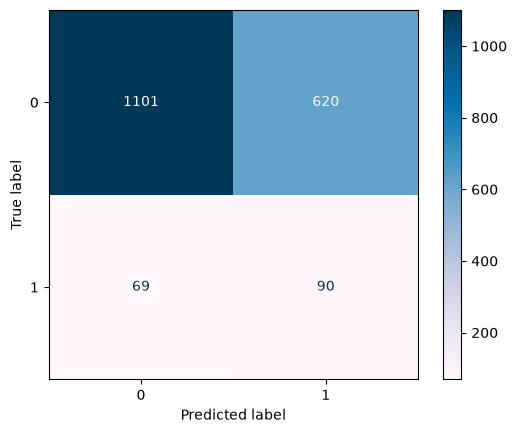


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.64      0.76      1721
           1       0.13      0.57      0.21       159

    accuracy                           0.63      1880
   macro avg       0.53      0.60      0.48      1880
weighted avg       0.87      0.63      0.71      1880



In [22]:
# Display confusion matrix and classification report for AL coverage
cm_al = confusion_matrix(y_al_test, y_pred_al)
cr_al = classification_report(y_al_test, y_pred_al)

disp_al = ConfusionMatrixDisplay(confusion_matrix=cm_al, display_labels=['0', '1'])
disp_al.plot(cmap="PuBu")
plt.show()
print("\nClassification Report:")
print(cr_al)

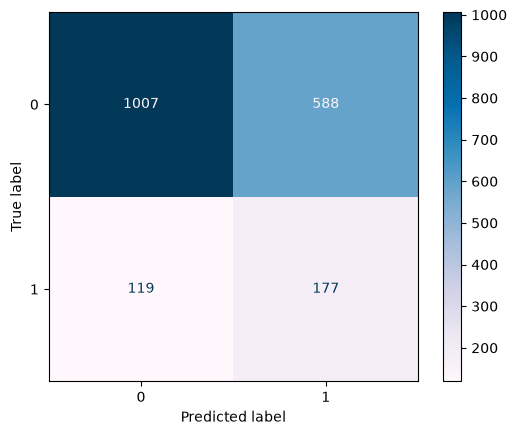


Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.63      0.74      1595
           1       0.23      0.60      0.33       296

    accuracy                           0.63      1891
   macro avg       0.56      0.61      0.54      1891
weighted avg       0.79      0.63      0.68      1891



In [23]:
# Display confusion matrix and classification report for APD coverage
cm_apd = confusion_matrix(y_apd_test, y_pred_apd)
cr_apd = classification_report(y_apd_test, y_pred_apd)

disp_apd = ConfusionMatrixDisplay(confusion_matrix=cm_apd, display_labels=['0', '1'])
disp_apd.plot(cmap="PuBu")
plt.show()
print("\nClassification Report:")
print(cr_apd)

In [24]:
# Save the best models for future use
joblib.dump(best_model_al, 'models/best_model_al.joblib')
joblib.dump(best_model_apd, 'models/best_model_apd.joblib')

['models/best_model_apd.joblib']